# Image Classification Project - Edge Impulse
By MJRovai @21Jan26

## Import Libraries

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from ai_edge_litert.interpreter import Interpreter

## Models to test

In [2]:
!ls ./models

ei-raspimageclass-transfer-learning-tensorflow-lite-float32-model.8.lite
ei-raspimageclass-transfer-learning-tensorflow-lite-int8-quantized-model.8.lite


## Test Dataset

In [3]:
!ls ./dataset

background  folha  óculos


In [4]:
!ls ./dataset/background

image_20260909-101116.jpg  image_20260909-101238.jpg  image_20260909-101428.jpg
image_20260909-101121.jpg  image_20260909-101241.jpg  image_20260909-101432.jpg
image_20260909-101124.jpg  image_20260909-101251.jpg  image_20260909-101438.jpg
image_20260909-101127.jpg  image_20260909-101300.jpg  image_20260909-101442.jpg
image_20260909-101131.jpg  image_20260909-101305.jpg  image_20260909-101449.jpg
image_20260909-101133.jpg  image_20260909-101309.jpg  image_20260909-101453.jpg
image_20260909-101146.jpg  image_20260909-101312.jpg  image_20260909-101457.jpg
image_20260909-101148.jpg  image_20260909-101316.jpg  image_20260909-101504.jpg
image_20260909-101153.jpg  image_20260909-101320.jpg  image_20260909-101507.jpg
image_20260909-101157.jpg  image_20260909-101324.jpg  image_20260909-101513.jpg
image_20260909-101203.jpg  image_20260909-101330.jpg  image_20260909-101515.jpg
image_20260909-101210.jpg  image_20260909-101335.jpg  image_20260909-101519.jpg
image_20260909-101213.jpg  image_2026090

In [5]:
!ls ./dataset/folha

image_20260909-094450.jpg  image_20260909-095603.jpg  image_20260909-095924.jpg
image_20260909-094511.jpg  image_20260909-095607.jpg  image_20260909-095931.jpg
image_20260909-094542.jpg  image_20260909-095635.jpg  image_20260909-095944.jpg
image_20260909-094557.jpg  image_20260909-095643.jpg  image_20260909-095950.jpg
image_20260909-094633.jpg  image_20260909-095651.jpg  image_20260909-095957.jpg
image_20260909-094643.jpg  image_20260909-095654.jpg  image_20260909-100002.jpg
image_20260909-094714.jpg  image_20260909-095657.jpg  image_20260909-100008.jpg
image_20260909-094724.jpg  image_20260909-095701.jpg  image_20260909-100017.jpg
image_20260909-094734.jpg  image_20260909-095705.jpg  image_20260909-100026.jpg
image_20260909-094821.jpg  image_20260909-095716.jpg  image_20260909-100044.jpg
image_20260909-094830.jpg  image_20260909-095720.jpg  image_20260909-100102.jpg
image_20260909-094834.jpg  image_20260909-095725.jpg  image_20260909-100111.jpg
image_20260909-094849.jpg  image_2026090

In [6]:
!ls ./dataset/óculos

image_20260909-100244.jpg  image_20260909-100518.jpg  image_20260909-100830.jpg
image_20260909-100249.jpg  image_20260909-100523.jpg  image_20260909-100837.jpg
image_20260909-100253.jpg  image_20260909-100540.jpg  image_20260909-100844.jpg
image_20260909-100259.jpg  image_20260909-100544.jpg  image_20260909-100849.jpg
image_20260909-100303.jpg  image_20260909-100558.jpg  image_20260909-100854.jpg
image_20260909-100311.jpg  image_20260909-100604.jpg  image_20260909-100900.jpg
image_20260909-100321.jpg  image_20260909-100608.jpg  image_20260909-100906.jpg
image_20260909-100336.jpg  image_20260909-100614.jpg  image_20260909-100914.jpg
image_20260909-100345.jpg  image_20260909-100618.jpg  image_20260909-100919.jpg
image_20260909-100350.jpg  image_20260909-100625.jpg  image_20260909-100925.jpg
image_20260909-100359.jpg  image_20260909-100629.jpg  image_20260909-100932.jpg
image_20260909-100402.jpg  image_20260909-100633.jpg  image_20260909-100945.jpg
image_20260909-100408.jpg  image_2026090

## Inspect Model

In [7]:
labels = ['background', 'folha', 'óculos']

In [8]:
print("Ordem que o código está usando:", labels)

Ordem que o código está usando: ['background', 'folha', 'óculos']


In [9]:
img_path = "./dataset/óculos/image_20260909-100249.jpg"
model_path = "./models/ei-raspimageclass-transfer-learning-tensorflow-lite-int8-quantized-model.8.lite"

In [10]:
    # Load the LiteRT model
    interpreter = Interpreter(model_path=model_path)
    interpreter.allocate_tensors()
    
    # Get input and output tensors
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [11]:
input_details

[{'name': 'serving_default_x:0',
  'index': 0,
  'shape': array([  1, 160, 160,   3], dtype=int32),
  'shape_signature': array([  1, 160, 160,   3], dtype=int32),
  'dtype': numpy.int8,
  'quantization': (0.003921568859368563, -128),
  'quantization_parameters': {'scales': array([0.00392157], dtype=float32),
   'zero_points': array([-128], dtype=int32),
   'quantized_dimension': 0,
   'block_size': 0},
  'sparsity_parameters': {}}]

In [12]:
 output_details

[{'name': 'StatefulPartitionedCall:0',
  'index': 172,
  'shape': array([1, 3], dtype=int32),
  'shape_signature': array([1, 3], dtype=int32),
  'dtype': numpy.int8,
  'quantization': (0.00390625, -128),
  'quantization_parameters': {'scales': array([0.00390625], dtype=float32),
   'zero_points': array([-128], dtype=int32),
   'quantized_dimension': 0,
   'block_size': 0},
  'sparsity_parameters': {}}]

In [13]:
# Get dtype of the input details of the model
input_dtype = input_details[0]['dtype']
input_dtype

numpy.int8

Now, the model is expecting a 'int8' dtype, what means that we should adapt the input image:

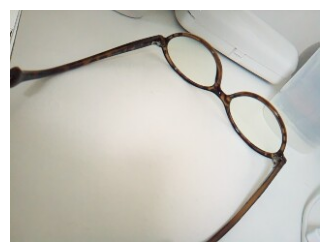

In [14]:
img = Image.open(img_path)
plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.axis('off')
plt.show()

## Pre-Processing

In [15]:
scale, zero_point = input_details[0]['quantization']
img = img.resize((input_details[0]['shape'][1], 
                  input_details[0]['shape'][2]))
img_array = np.array(img, dtype=np.float32) / 255.0
img_array = (img_array / scale + zero_point).clip(-128, 127).astype(np.int8)
input_data = np.expand_dims(img_array, axis=0)
input_data.shape, input_data.dtype

((1, 160, 160, 3), dtype('int8'))

## Inference

In [16]:
# Inference on Raspi-Zero
start_time = time.time()
interpreter.set_tensor(input_details[0]['index'], input_data)
interpreter.invoke()
end_time = time.time()
inference_time = (end_time - start_time) * 1000  # Convert to milliseconds
print ("Inference time: {:.1f}ms".format(inference_time))

Inference time: 89.3ms


In [17]:
# Obtain results and map them to the classes
predictions = interpreter.get_tensor(output_details[0]['index'])[0]
predictions

array([-128, -128,  127], dtype=int8)

In [18]:
# Get indices of the top k results
top_k_results=3
top_k_indices = np.argsort(predictions)[::-1][:top_k_results]
top_k_indices

array([2, 1, 0])

In [19]:
# Get quantization parameters
scale, zero_point = output_details[0]['quantization']

# Dequantize the output
dequantized_output = (predictions.astype(np.float32) - zero_point) * scale
dequantized_output

array([0.        , 0.        , 0.99609375], dtype=float32)

The model already has a softmax in its output, and so, we can use its raw output as the "probabilities".

In [20]:
# exp_output = np.exp(dequantized_output - np.max(dequantized_output))
# probabilities = exp_output / np.sum(exp_output)
probabilities = dequantized_output

In [21]:
print("\n\t[PREDICTION]        [Prob]\n")
for i in range(top_k_results):
    print("\t{:20}: {:.2f}%".format(
        labels[top_k_indices[i]],
        probabilities[top_k_indices[i]] * 100))


	[PREDICTION]        [Prob]

	óculos              : 99.61%
	folha               : 0.00%
	background          : 0.00%


Let's use a non quantized model

In [30]:
img_path = "./dataset/folha/image_20260909-094734.jpg"
model_path = "./models/ei-raspimageclass-transfer-learning-tensorflow-lite-float32-model.8.lite"

In [31]:
    # Load the LiteRT model
    interpreter = Interpreter(model_path=model_path)
    interpreter.allocate_tensors()
    
    # Get input and output tensors
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

In [32]:
input_details

[{'name': 'serving_default_x:0',
  'index': 0,
  'shape': array([  1, 160, 160,   3], dtype=int32),
  'shape_signature': array([  1, 160, 160,   3], dtype=int32),
  'dtype': numpy.float32,
  'quantization': (0.0, 0),
  'quantization_parameters': {'scales': array([], dtype=float32),
   'zero_points': array([], dtype=int32),
   'quantized_dimension': 0,
   'block_size': 0},
  'sparsity_parameters': {}}]

In [33]:
output_details

[{'name': 'StatefulPartitionedCall:0',
  'index': 172,
  'shape': array([1, 3], dtype=int32),
  'shape_signature': array([1, 3], dtype=int32),
  'dtype': numpy.float32,
  'quantization': (0.0, 0),
  'quantization_parameters': {'scales': array([], dtype=float32),
   'zero_points': array([], dtype=int32),
   'quantized_dimension': 0,
   'block_size': 0},
  'sparsity_parameters': {}}]

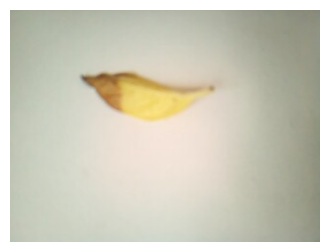

In [34]:
img = Image.open(img_path)
plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.axis('off')
plt.show()

In [35]:
# Get dtype of the input details of the model
input_dtype = input_details[0]['dtype']
input_dtype

numpy.float32

Now, the model is expecting an input as a float32, so, let's normalize the data to [0,1]. 

In [36]:
img = img.resize((input_details[0]['shape'][1], 
                  input_details[0]['shape'][2]))
img_array = np.array(img, dtype=np.float32) / 255.0
input_data = np.expand_dims(img_array, axis=0)
input_data.shape, input_data.dtype

((1, 160, 160, 3), dtype('float32'))

In [37]:
# Inference on Raspi-Zero
start_time = time.time()
interpreter.set_tensor(input_details[0]['index'], input_data)
interpreter.invoke()
end_time = time.time()
inference_time = (end_time - start_time) * 1000  # Convert to milliseconds
print ("Inference time: {:.1f}ms".format(inference_time))

Inference time: 108.5ms


In [38]:
# Obtain results and map them to the classes
predictions = interpreter.get_tensor(output_details[0]['index'])[0]

In [39]:
predictions

array([3.8994492e-09, 1.0000000e+00, 2.3639413e-12], dtype=float32)

In [40]:
# Get indices of the top k results
top_k_results=3
top_k_indices = np.argsort(predictions)[::-1][:top_k_results]

In [41]:
top_k_indices

array([1, 0, 2])

In [42]:
print("\n\t[PREDICTION]        [Prob]\n")
for i in range(top_k_results):
    print("\t{:20}: {}%".format(
        labels[top_k_indices[i]],
            (int(predictions[top_k_indices[i]]*100))))


	[PREDICTION]        [Prob]

	folha               : 100%
	background          : 0%
	óculos              : 0%


### Function to handle any type of models 

In [43]:
def image_classification(img_path, model_path, labels, top_k_results=3, apply_softmax=False):
    # Load the image
    img = Image.open(img_path)
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis('off')

    # Load the LiteRT model
    interpreter = Interpreter(model_path=model_path)
    interpreter.allocate_tensors()

    # Get input and output tensors
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    # Preprocess
    img = img.resize((input_details[0]['shape'][1], 
                      input_details[0]['shape'][2]))
    
    input_dtype = input_details[0]['dtype']
    
    if input_dtype == np.uint8:
        input_data = np.expand_dims(np.array(img), axis=0)
    elif input_dtype == np.int8:
        scale, zero_point = input_details[0]['quantization']
        img_array = np.array(img, dtype=np.float32) / 255.0
        img_array = (img_array / scale + zero_point).clip(-128, 127).astype(np.int8)
        input_data = np.expand_dims(img_array, axis=0)
    else:  # float32
        input_data = np.expand_dims(np.array(img, dtype=np.float32), axis=0) / 255.0

    # Inference on Raspi-Zero
    start_time = time.time()
    interpreter.set_tensor(input_details[0]['index'], input_data)
    interpreter.invoke()
    end_time = time.time()
    inference_time = (end_time - start_time) * 1000  # Convert to milliseconds

    # Obtain results
    predictions = interpreter.get_tensor(output_details[0]['index'])[0]

    # Get indices of the top k results
    top_k_indices = np.argsort(predictions)[::-1][:top_k_results]

    # Handle output based on type
    output_dtype = output_details[0]['dtype']
    if output_dtype in [np.int8, np.uint8]:
        # Dequantize the output
        scale, zero_point = output_details[0]['quantization']
        predictions = (predictions.astype(np.float32) - zero_point) * scale
    
    if apply_softmax:
        # Apply softmax
        exp_preds = np.exp(predictions - np.max(predictions))
        probabilities = exp_preds / np.sum(exp_preds)
    else:
        probabilities = predictions

    print("\n\t[PREDICTION]        [Prob]\n")
    for i in range(top_k_results):
        print("\t{:20}: {:.1f}%".format(
            labels[top_k_indices[i]],
            probabilities[top_k_indices[i]] * 100))
    print ("\n\tInference time: {:.1f}ms".format(inference_time))

# Usage:
# image_classification('path_to_image.jpg', 'path_to_model.tflite', labels)


	[PREDICTION]        [Prob]

	folha               : 99.6%
	óculos              : 0.0%
	background          : 0.0%

	Inference time: 65.4ms


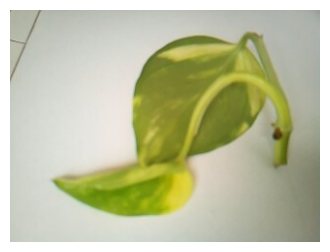

In [47]:
img_path = "./dataset/folha/image_20260909-094542.jpg"
model_path = "./models/ei-raspimageclass-transfer-learning-tensorflow-lite-int8-quantized-model.8.lite"
labels = ['background', 'folha', 'óculos']
image_classification(img_path, model_path, labels, top_k_results=len(labels))


	[PREDICTION]        [Prob]

	folha               : 100.0%
	óculos              : 0.0%
	background          : 0.0%

	Inference time: 94.2ms


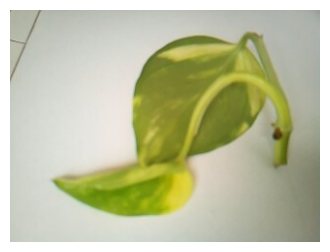

In [48]:
img_path = "./dataset/folha/image_20260909-094542.jpg"
model_path = "./models/ei-raspimageclass-transfer-learning-tensorflow-lite-float32-model.8.lite"
labels = ['background', 'folha', 'óculos']
image_classification(img_path, model_path, labels, top_k_results=len(labels))


	[PREDICTION]        [Prob]

	óculos              : 99.6%
	folha               : 0.0%
	background          : 0.0%

	Inference time: 65.7ms


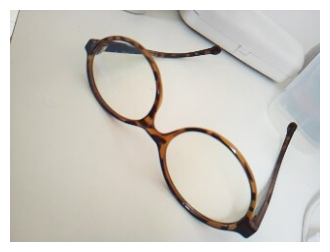

In [57]:
img_path = "./dataset/óculos/image_20260909-100244.jpg"
model_path = "./models/ei-raspimageclass-transfer-learning-tensorflow-lite-int8-quantized-model.8.lite"
labels = ['background', 'folha', 'óculos']
image_classification(img_path, model_path, labels, top_k_results=len(labels))


	[PREDICTION]        [Prob]

	óculos              : 100.0%
	background          : 0.0%
	folha               : 0.0%

	Inference time: 93.7ms


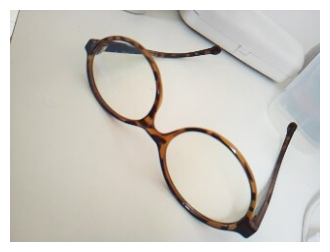

In [58]:
img_path = "./dataset/óculos/image_20260909-100244.jpg"
model_path = "./models/ei-raspimageclass-transfer-learning-tensorflow-lite-float32-model.8.lite"
labels = ['background', 'folha', 'óculos']
image_classification(img_path, model_path, labels, top_k_results=len(labels))


	[PREDICTION]        [Prob]

	background          : 99.6%
	óculos              : 0.0%
	folha               : 0.0%

	Inference time: 65.1ms


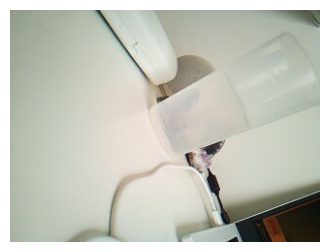

In [53]:
img_path = "./dataset/background/image_20260909-101227.jpg"
model_path = "./models/ei-raspimageclass-transfer-learning-tensorflow-lite-int8-quantized-model.8.lite"
labels = ['background', 'folha', 'óculos']
image_classification(img_path, model_path, labels, top_k_results=len(labels))


	[PREDICTION]        [Prob]

	background          : 100.0%
	óculos              : 0.0%
	folha               : 0.0%

	Inference time: 93.7ms


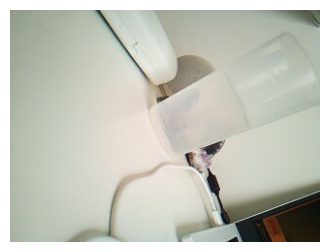

In [54]:
img_path = "./dataset/background/image_20260909-101227.jpg"
model_path = "./models/ei-raspimageclass-transfer-learning-tensorflow-lite-float32-model.8.lite"
labels = ['background', 'folha', 'óculos']
image_classification(img_path, model_path, labels, top_k_results=len(labels))

## Testing a smaller model (optional)

Model can be downloded from: https://studio.edgeimpulse.com/public/353482/live


	[PREDICTION]        [Prob]

	periquito           : 96.5%
	background          : 3.5%
	robot               : 0.0%

	Inference time: 0.5ms


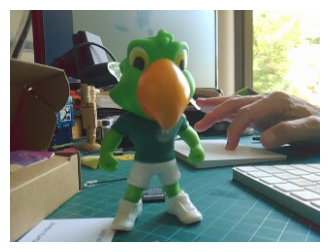

In [41]:
img_path = "./dataset/periquito/image_20260121-144529.jpg"
model_path = "./models/ei-periquito-vs-robot-img-class-int8-quantized-model.lite"
labels = ['background', 'periquito', 'robot']
image_classification(img_path, model_path, labels, top_k_results=len(labels))


	[PREDICTION]        [Prob]

	robot               : 94.1%
	periquito           : 5.1%
	background          : 0.8%

	Inference time: 0.5ms


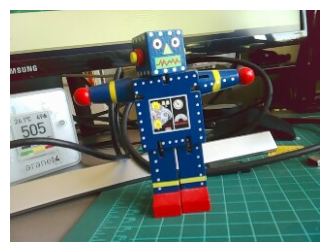

In [42]:
img_path = "./dataset/robot/image_20260121-145927.jpg"
model_path = "./models/ei-periquito-vs-robot-img-class-int8-quantized-model.lite"
labels = ['background', 'periquito', 'robot']
image_classification(img_path, model_path, labels, top_k_results=len(labels))


	[PREDICTION]        [Prob]

	background          : 99.6%
	robot               : 0.0%
	periquito           : 0.0%

	Inference time: 0.8ms


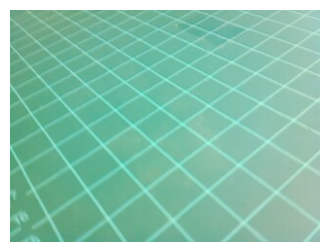

In [43]:
img_path = "./dataset/background/image_20260121-150030.jpg"
model_path = "./models/ei-periquito-vs-robot-img-class-int8-quantized-model.lite"
labels = ['background', 'periquito', 'robot']
image_classification(img_path, model_path, labels, top_k_results=len(labels))

## Classifying Images from the Camera

In [44]:
from picamera2 import Picamera2

In [45]:
def capture_image(image_path):
    
  # Initialize camera
  picam2 = Picamera2() # default is index 0

  # Configure the camera
  config = picam2.create_still_configuration(main={"size": (224, 224)})
  picam2.configure(config)
  picam2.start()

  # Wait for the camera to warm up
  time.sleep(2)

  # Capture image
  picam2.capture_file(image_path)
  print("Image captured: "+image_path)

  # Stop camera
  picam2.stop()
  picam2.close()

[4:51:55.680213144] [4737]  INFO Camera camera.cpp:1215 configuring streams: (0) 224x224-BGR888/sRGB (1) 640x480-GBRG_PISP_COMP1/RAW
[4:51:55.680345275] [4704]  INFO RPI pisp.cpp:1485 Sensor: /base/axi/pcie@1000120000/rp1/i2c@88000/ov5647@36 - Selected sensor format: 640x480-SGBRG10_1X10/RAW - Selected CFE format: 640x480-PC1g/RAW


Image captured: ./images/cam_img_test_2.jpg

	[PREDICTION]        [Prob]

	robot               : 99.6%
	periquito           : 0.0%
	background          : 0.0%

	Inference time: 8.3ms


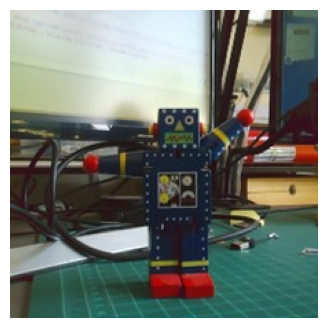

In [48]:
img_path = './images/cam_img_test_2.jpg'
model_path = "./models/ei-raspi-img-class-int8-quantized-model.tflite"
labels = ['background', 'periquito', 'robot']
capture_image(img_path)
image_classification(img_path, model_path, labels, top_k_results=len(labels))